Window Haze: 1271


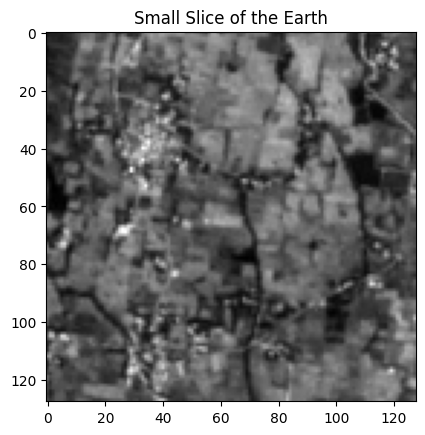

In [11]:
import matplotlib.pyplot as plt
import numpy as np 
import rasterio
from rasterio.windows import Window

file_path = r"C:\Users\hsgpi\OneDrive\Desktop\S2C_MSIL2A_20260213T045921_N0512_R119_T44QQE_20260213T133817.SAFE\GRANULE\L2A_T44QQE_A007525_20260213T051019\IMG_DATA\R10m\B04_10m.jp2"
my_window  = Window(1000, 2000, 128, 128)
with rasterio.open(file_path) as src:
    image_window=src.read(1, window=my_window)
    haze_value = image_window.min()
    corrected = image_window - haze_value
    print(f"Window Haze: {haze_value}")

    plt.imshow(image_window, cmap='gray')
    plt.title("Small Slice of the Earth")
    plt.show()


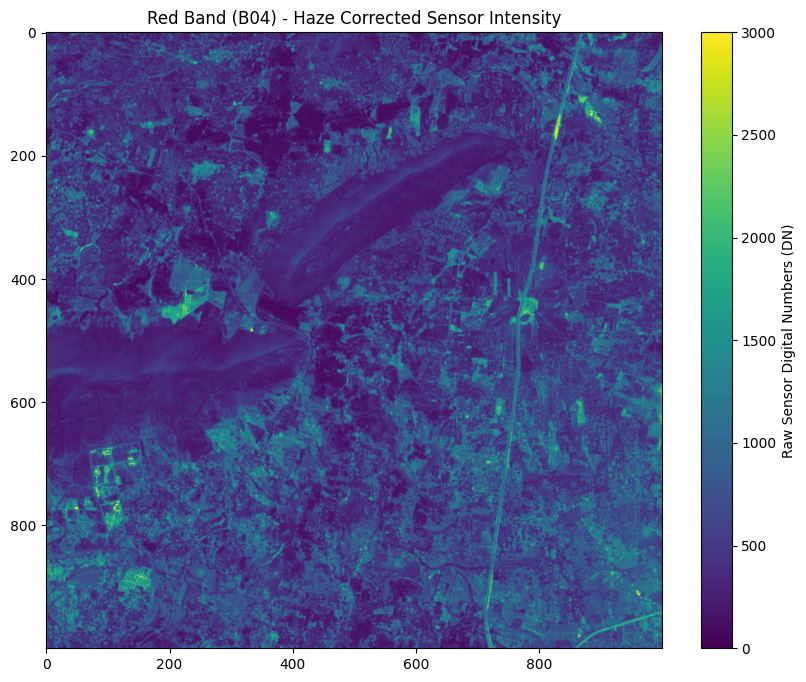

In [ ]:
import rasterio
from rasterio.windows import Window
import matplotlib.pyplot as plt

file_path = r"C:\Users\hsgpi\OneDrive\Desktop\S2C_MSIL2A_20260213T045921_N0512_R119_T44QQE_20260213T133817.SAFE\GRANULE\L2A_T44QQE_A007525_20260213T051019\IMG_DATA\R10m\B04_10m.jp2"

with rasterio.open(file_path) as src:
    # A 1000x1000 pixel window (10km x 10km)
    my_window = Window(2000, 2000, 1000, 1000)
    raw_data = src.read(1, window=my_window)
    haze_value = raw_data.min()
    corrected_data = raw_data - haze_value
    plt.figure(figsize=(10, 8))
    
    # No 'cmap' specified = Raw Viridis color mapping
    # vmin and vmax ensure the colors aren't "washed out"
    img = plt.imshow(corrected_data, vmin=0, vmax=3000) 
    
    # This is the most important part: The 'Scale'
    plt.colorbar(img, label='Raw Sensor Digital Numbers (DN)')
    
    plt.title("Red Band (B04) - Haze Corrected Sensor Intensity")
    plt.show()